# Music Genre Classification using multi-level perceptron (MLP) and Mel Spectograms

## 0. Importing libraries, setting up device agnostic code

We start by importing the main needed libraries to run the script. Then we check the GPU properties and set up device agnostic code. In this manner, if a GPU is available, it will be used. Also we set a random seed so that a fixed seed will maintain consistency in experimental results. This will also make it easier to compare different approaches.

In [1]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torchaudio
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchaudio.__version__)

2.7.0+cu118
2.7.0+cu118


In [2]:
# Set random seeds
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
!nvidia-smi

Thu Feb  5 11:08:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   41C    P8            N/A  /  115W |    1034MiB /   8188MiB |      5%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Loading data

We load the data from the respective `.json` file in the current directory. Data is loaded as numpy arrays. Those arrays are used to create PyTorch tensors.



In [5]:
# Create method to load mel spectogram data from json file
def load_data(dataset_path):
    with open(dataset_path, 'r') as fp:
        data = json.load(fp)

    # Convert
    inputs = np.array(data['melspec'])
    targets = np.array(data['labels'])

    return inputs, targets

In [6]:
# Create function to load classes from .json file
def load_classes(dataset_path):
    with open(dataset_path, 'r') as fp:
        data = json.load(fp)
    classes = data['mapping']
    return classes

In [7]:
# Load classes
DATASET_PATH = "data_full.json"

classes = load_classes(DATASET_PATH)
print(classes)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [8]:
# Load data and see the shape. 130 time frames and 128 mel bands
inputs, labels = load_data(DATASET_PATH)
inputs.shape, labels.shape

((9996, 130, 128), (9996,))

In [9]:
# Turn data into tensors, also unsqueeze and permute, to be ready for CNN
X = torch.from_numpy(inputs).float() # Weight calculations expect float
y = torch.from_numpy(labels).long() # CrossEntropyLoss expects long
X = X.permute(0, 2, 1)
X.shape, y.shape

(torch.Size([9996, 128, 130]), torch.Size([9996]))

## 2. Create DataSets and DataLoaders

In order to use the data in our model, we have to organize it into PyTorch DataLoaders.
After loading the data, we split them into three sets: train_set, validation_set and test_set. The validation_set will be used during the training for evaluation. The test_set will be used after the model is ready. In order for it to be exposed in never seen data.

After dividing the sets, we create the respective datasets and dataloaders.

In [10]:
# Creating a function to divide the sets
def divide_sets(X, y, test_size, validation_size, random_state=None):

    # create train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # create train/validation split
    X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=validation_size, random_state=random_state)

    return X_train, X_validation, X_test, y_train, y_validation, y_test

In [11]:
# Create train, validation and test sets test size is 25% of the whole set. Validation size is 20% of the remaining train_set
X_train, X_validation, X_test, y_train, y_validation, y_test = divide_sets(X, y, test_size=0.25,
                                                                                validation_size=0.2,
                                                                                random_state=RANDOM_SEED)


In [12]:
# Check if data is divided correctly
print(X.shape[0] == X_train.shape[0] + X_validation.shape[0] + X_test.shape[0])
print(y.shape[0] == y_train.shape[0] + y_validation.shape[0] + y_test.shape[0])

True
True


In [13]:
# Create datasets and dataloaders
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE=32
torch.manual_seed(RANDOM_SEED)

train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)
validation_dataloader = DataLoader(validation_dataset,
                                   batch_size=BATCH_SIZE,)
test_dataloader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of validation dataloader: {len(validation_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000024C7F21C050>, <torch.utils.data.dataloader.DataLoader object at 0x0000024C7F1279D0>)
Length of train dataloader: 188 batches of 32
Length of validation dataloader: 47 batches of 32
Length of test dataloader: 79 batches of 32


In [14]:
# Checking the dataset shapes using test_dataloader
test_features_batch, test_labels_batch = next(iter(test_dataloader))
print(test_features_batch.shape, "-> (batch_size, num_channels, mel_bands, time_frames)")
print(test_labels_batch.shape, "-> (batch_size,) each entry is the class index of a sample)")
print(test_features_batch[0].shape, "-> (mel_bands, time_frames)")
print(test_labels_batch[0], "-> (label)")

torch.Size([32, 128, 130]) -> (batch_size, num_channels, mel_bands, time_frames)
torch.Size([32]) -> (batch_size,) each entry is the class index of a sample)
torch.Size([128, 130]) -> (mel_bands, time_frames)
tensor(1) -> (label)


## 2. Data visualization

For better perception of the subject, we implement some visualization of the data. We use matplotlib libraries to visualize a Mel Spectogram of a random example. The data has to be turned into numpy arrays in order to be processed by matplotlib.
In the picture, we can see that the y-axis has the mel bins in an appropriate scale, as we use 64 bands/bins.


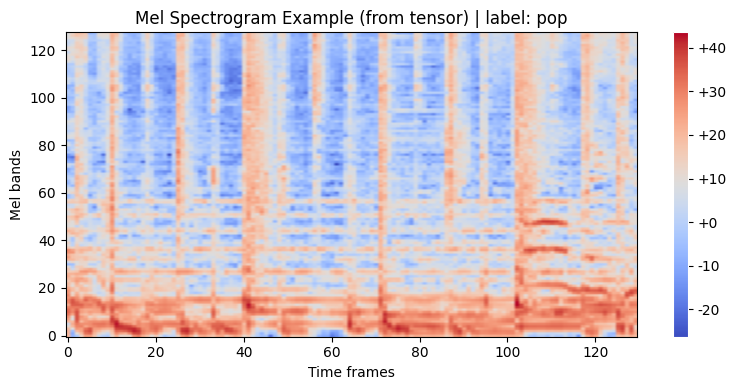

In [15]:
# Visualise data
np.random.seed(RANDOM_SEED)

# Select sample
CLASS_NUM = np.random.randint(len(X))
melspec_example = X[CLASS_NUM].numpy()

# Create figure and axes with consistent style
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Display Mel Spectrogram
img = ax.imshow(
    melspec_example,
    cmap='coolwarm',
    aspect='auto',
    origin='lower'
)

# Colorbar with formatted ticks
cbar = plt.colorbar(img, ax=ax, format="%+2.f")
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

# Axes labels
ax.set_xlabel("Time frames", color='black')
ax.set_ylabel("Mel bands", color='black')

# Tick colors
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# Axis spines
for spine in ax.spines.values():
    spine.set_color('black')

# Add dynamic title
ax.set_title(f"Mel Spectrogram Example (from tensor) | label: {classes[y[CLASS_NUM]]}", color='black')

# Tight layout
plt.tight_layout()

# # Save the figure
# plt.savefig(
#     "MFCC_example.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

# Show figure
plt.show()

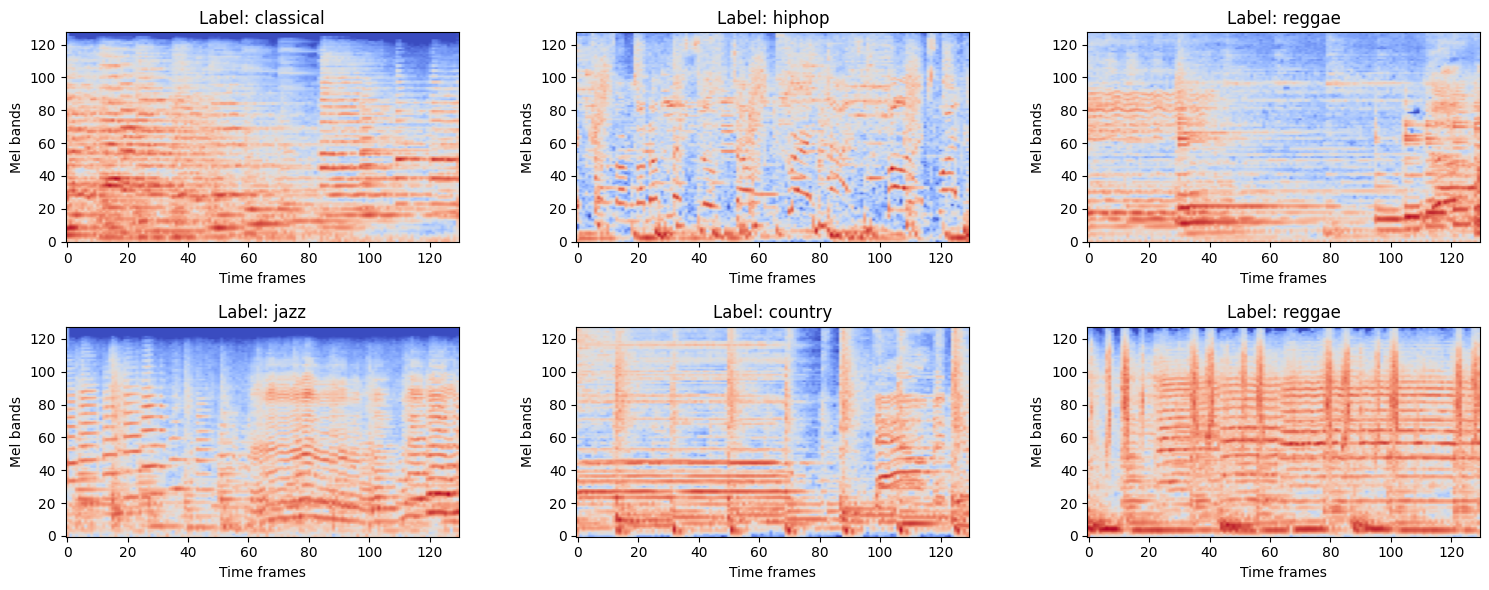

In [16]:
# Visualize different genres with consistent style

# Select example
np.random.seed(RANDOM_SEED)
indices = np.random.choice(len(X), size=6, replace=False)

fig, axs = plt.subplots(2, 3, figsize=(15, 6))
fig.patch.set_facecolor('white')

# Loop for each MFCC graph
for i, idx in enumerate(indices):
    row = i // 3
    col = i % 3

    melspec_example = X[idx].numpy()
    ax = axs[row, col]

    # White background per subplot
    ax.set_facecolor('white')

    # Display MFCC
    img = ax.imshow(
        melspec_example,
        cmap='coolwarm',
        aspect='auto',
        origin='lower'
    )

    # # Colorbar (same style as before)
    # cbar = plt.colorbar(img, ax=ax, format="%+2.f")
    # cbar.ax.yaxis.set_tick_params(color='black')
    # plt.setp(cbar.ax.get_yticklabels(), color='black')

    # Subplot title (KEEP IT)
    ax.set_title(f"Label: {classes[y[idx]]}", color='black')

    # Set labels
    ax.set_xlabel("Time frames", color='black')
    ax.set_ylabel("Mel bands", color='black')

    # Ticks styling
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')


    # Axis spines
    for spine in ax.spines.values():
        spine.set_color('black')

# Layout (no constrained / no hacks)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# # Save figure
# plt.savefig(
#     "MFCC_examples_genres.png",
#     dpi=144, ='tight',
#     facecolor=fig.get_facecolor()
# )

plt.show()


## 4. Building a basic MLP model

The architecture of the model is based on a basic multi layer neural network. It consists of `nn.Linear()` layers and we use the `ReLu()` activation for each. First, we use an `nn.flatten()` layer because such architectures need to have vectors as in features. Those vectors have initially the tensor dimensions compressed. So in our case we input the `num_features` where `num_features = input_shape[0] * input_shape[1]`. Those two values will actually be the _time_frames * mel_bands_ which is actually 130 * 64 = 8320.

This model will output logits. We can apply an `nn.Softmax()` function to those logits in order to get probabilities. However it is good practise to do this later. Furthermore we are going to use `nn.CrossEntropyLoss` later and this method takes logits as arguments.

**Important**: Our model expects a fixed input shape of (130, 64)

Futhermore, we use `summary()` from the torchinfo library to have a detailed perspective of the model.

In [17]:
# Build the network architecture
NUM_CLASSES = 10
INPUT_SHAPE = (inputs.shape[1], inputs.shape[2]) # INPUT_SHAPE = (130, 128)

class MLPClassifierV0(nn.Module):
    def __init__(self, input_shape, num_classes=10):
        super().__init__()

        num_features = input_shape[0] * input_shape[1]

        self.flatten = nn.Flatten()
        self.layer_1 = nn.Linear(num_features, 512)
        self.layer_2 = nn.Linear(512, 256)
        self.layer_3 = nn.Linear(256, 64)
        self.output = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        x = self.relu(x)
        x = self.layer_3(x)
        x = self.relu(x)
        x = self.output(x)
        return x

In [18]:
# Create a model and put it to device
NUM_CLASSES = 10
INPUT_SHAPE = (X.shape[1], X.shape[2]) # INPUT_SHAPE = (130, 13)

torch.manual_seed(RANDOM_SEED)
model_0 = MLPClassifierV0(input_shape=INPUT_SHAPE,
                          num_classes=NUM_CLASSES).to(device)
print(model_0)
print(next(model_0.parameters()).device)

MLPClassifierV0(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer_1): Linear(in_features=16640, out_features=512, bias=True)
  (layer_2): Linear(in_features=512, out_features=256, bias=True)
  (layer_3): Linear(in_features=256, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)
cuda:0


In [19]:
# Perform a single forward pass on the data (we'll need to put it to the target device for it to work)
model_0.eval()
logits = model_0(X.to(device))
probs = torch.softmax(logits, dim=1)
print(logits[:5])
print(probs[:5])

tensor([[-1.1047, -0.2462, -0.1517,  0.2708,  0.4475, -0.5475,  0.1801, -0.3162,
          1.3410,  1.0814],
        [-1.0563, -0.1124,  0.0922,  0.0373, -0.0228, -0.2959,  0.1935, -0.0790,
          1.7229,  0.8199],
        [-0.4283, -0.3889, -0.1236, -0.1479, -0.3871, -1.0480,  0.2875,  0.4018,
          1.7562,  1.0329],
        [-0.9088, -0.4490, -0.2375,  0.6069,  0.0662,  0.2014, -0.6403, -0.4436,
          1.4297,  1.2316],
        [-1.2429, -0.2280,  0.0606,  0.0786, -0.0131, -0.6494,  0.1842,  0.5135,
          1.8989,  1.1739]], device='cuda:0', grad_fn=<SliceBackward0>)
tensor([[0.0235, 0.0554, 0.0608, 0.0928, 0.1108, 0.0409, 0.0848, 0.0516, 0.2707,
         0.2088],
        [0.0230, 0.0592, 0.0726, 0.0687, 0.0647, 0.0492, 0.0803, 0.0612, 0.3708,
         0.1503],
        [0.0420, 0.0436, 0.0569, 0.0555, 0.0437, 0.0226, 0.0858, 0.0962, 0.3728,
         0.1809],
        [0.0274, 0.0433, 0.0535, 0.1246, 0.0725, 0.0830, 0.0358, 0.0436, 0.2836,
         0.2326],
        [0.0165

In [20]:
# Have a summary of the model
from torchinfo import summary

summary(model_0, input_size=(BATCH_SIZE, inputs.shape[1], inputs.shape[2]))

Layer (type:depth-idx)                   Output Shape              Param #
MLPClassifierV0                          [32, 10]                  --
├─Flatten: 1-1                           [32, 16640]               --
├─Linear: 1-2                            [32, 512]                 8,520,192
├─ReLU: 1-3                              [32, 512]                 --
├─Linear: 1-4                            [32, 256]                 131,328
├─ReLU: 1-5                              [32, 256]                 --
├─Linear: 1-6                            [32, 64]                  16,448
├─ReLU: 1-7                              [32, 64]                  --
├─Linear: 1-8                            [32, 10]                  650
Total params: 8,668,618
Trainable params: 8,668,618
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 277.40
Input size (MB): 2.13
Forward/backward pass size (MB): 0.22
Params size (MB): 34.67
Estimated Total Size (MB): 37.02

## 5. Training the model

We start by setting a loss function and an optimizer. Two crucial elements of the training procedure.
A helper function named `accuracy_fn()` is going to help us calculate the accuracy. We could use `torchmetrics.accuracy()`, but instead one can implement it.
The training pipeling includes defining a dictionary for the results. This will help later on with the plots that will give us a view on how the model performs. The training also involves batching, so loss and accuracy is calculated for each batch and the result is accumulated.

In [21]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.001,
                             weight_decay=0.001)

In [22]:
# Create a train loop function
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [23]:
# Create test loop function
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [24]:
# Create train function by combining train_step and test_step
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [25]:
# Train the model
# Set number of epochs
NUM_EPOCHS = 50

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=validation_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.8706 | train_acc: 0.1473 | test_loss: 2.2746 | test_acc: 0.1272
Epoch: 2 | train_loss: 2.3040 | train_acc: 0.1046 | test_loss: 2.2987 | test_acc: 0.0968
Epoch: 3 | train_loss: 2.2937 | train_acc: 0.1398 | test_loss: 2.3017 | test_acc: 0.0968
Epoch: 4 | train_loss: 2.2934 | train_acc: 0.1138 | test_loss: 2.3016 | test_acc: 0.0975
Epoch: 5 | train_loss: 2.2242 | train_acc: 0.1513 | test_loss: 2.1591 | test_acc: 0.1867
Epoch: 6 | train_loss: 2.1665 | train_acc: 0.1743 | test_loss: 2.1559 | test_acc: 0.1707
Epoch: 7 | train_loss: 2.1702 | train_acc: 0.1736 | test_loss: 2.1461 | test_acc: 0.1733
Epoch: 8 | train_loss: 2.1381 | train_acc: 0.1827 | test_loss: 2.1074 | test_acc: 0.1890
Epoch: 9 | train_loss: 2.0640 | train_acc: 0.2003 | test_loss: 2.0604 | test_acc: 0.1793
Epoch: 10 | train_loss: 2.0295 | train_acc: 0.2123 | test_loss: 2.0477 | test_acc: 0.2244
Epoch: 11 | train_loss: 2.0030 | train_acc: 0.2285 | test_loss: 2.0264 | test_acc: 0.2382
Epoch: 12 | train_l

## 6. Plotting the results

We define a helper method to plot the results. We then use matplotlib to plot how our model performed.

In [26]:
# Check the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [27]:
# defining the plot function
from typing import Tuple, Dict, List
def plot_loss_curves(results: Dict[str, List[float]],
                     Save = False):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup figure
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))
    fig.patch.set_facecolor('white')

    # ===== Loss plot =====
    axs[0].set_facecolor('white')

    axs[0].plot(epochs, loss, label='train_loss', color="#4195C1")
    axs[0].plot(epochs, test_loss, label='test_loss', color="#FF7B22")

    axs[0].set_title('Loss', color='black')
    axs[0].set_xlabel('Epochs', color='black')

    axs[0].tick_params(axis='x', colors='black')
    axs[0].tick_params(axis='y', colors='black')

    for spine in axs[0].spines.values():
        spine.set_color('black')

    axs[0].legend(frameon=True,
                  facecolor='white',
                  edgecolor='black',
                  labelcolor='black'
                  )

    # ===== Accuracy plot =====
    axs[1].set_facecolor('white')

    axs[1].plot(epochs, accuracy, label='train_accuracy', color="#4195C1")
    axs[1].plot(epochs, test_accuracy, label='test_accuracy', color="#FF7B22")

    axs[1].set_title('Accuracy', color='black')
    axs[1].set_xlabel('Epochs', color='black')

    axs[1].tick_params(axis='x', colors='black')
    axs[1].tick_params(axis='y', colors='black')

    for spine in axs[1].spines.values():
        spine.set_color('black')

    axs[1].legend(frameon=True,
                  facecolor='white',
                  edgecolor='black',
                  labelcolor='black'
                  )

    # Layout
    plt.tight_layout()

    # Save figure
    if Save:
        plt.savefig(
            "training_curves.png",
            dpi=144,
            bbox_inches='tight',
            facecolor=fig.get_facecolor()
        )

    plt.show()

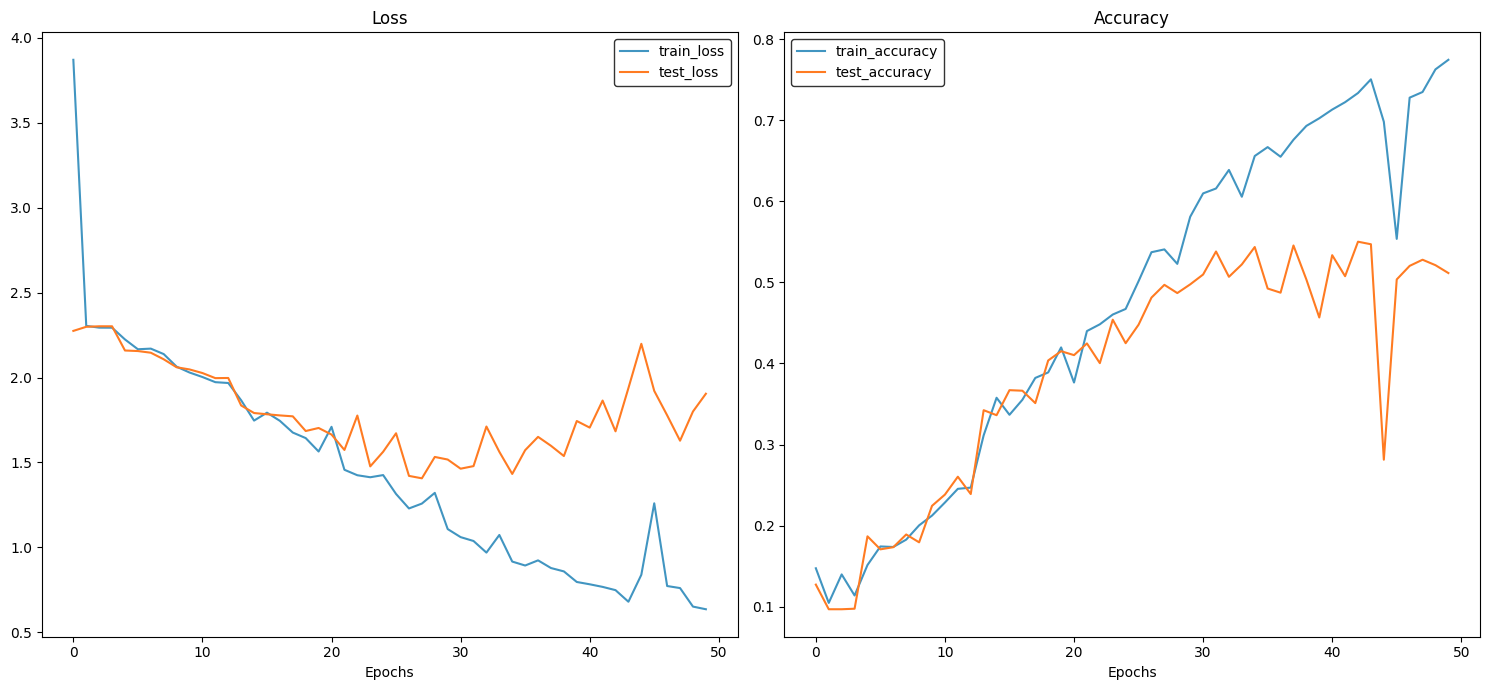

In [28]:
plot_loss_curves(model_0_results)

## 7. Using Data Augmentation

For our next model we are going to use data augmentation. This is a very common method to avoid overfitting. The method works as following:

During training, the model is exposed to the same data during each epoch. When implementing data augmentation, we alter the data on each epoch. In this way, the model is exposed to different data on each epoch, thus increasing the variety of data that it is exposed to. On each epoch a random alternation on the data is applied.

### 7.1 Implementing `TimeMasking()` and `FrequencyMasking()` on the data
The data augmentation we are going to use is `TimeMasking()` and `FrequencyMasking()`, both from the `torchaudio` library. Those methods will randomly mask up to a number of time frames and coefficients respectively. For more info - https://docs.pytorch.org/audio/main/tutorials/audio_feature_augmentation_tutorial.html#time-and-frequency-masking


> The `TimeMasking()` transform, "masks" the entire x axis for a specific amount. A good option would be to mask 15% of the sample. The *time_mask_param* is responsible for the amount of time frames that will be masked. We are calculating this value and setting it in the `TimeMasking()` transform.
>> __In case we divided the original GTZAN samples into 10 segments__: Our x axis is the time frames and we know that each sample has 130 time frames. We are going to mask 20 frames which is approximately 15% of the sample. This is done by setting the *time_mask_param* to 20. That means that maximum 20 consecutive frames will be masked.

> The `FrequencyMasking()` transform, "masks" the entire y axis for a specific amount. A good option would be to mask 12% of the sample. The *freq_mask_param* is responsible for the amount of mel bands that will be masked. We are calculating this value and setting it in the `FrequencyMasking()` transform.
>> __In case we divided the original GTZAN samples into 10 segments__:Our y axis is the mel bands and we know that each sample has 64 mel bands. We are going to mask 8 frames which is approximately 12% of the sample. This is done by setting the *freq_mask_param* to 8. That means that maximum 8 consecutive frames will be masked.

The masked spectograms are presented, to have a visualization of the augmented data. Similar methods of masking on log mel spectograms directly are mentioned in the SpecAugment paper. More info here - https://arxiv.org/pdf/1904.08779

_**Notice**: The time_mask_param and freq_mask_param will set the **maximum** amount of frames/MFCCs that will be masked. This number will be random on each epoch._

In [29]:
# Calculating the proper time_mask_param anf freq_mask_param values
mel_bands = inputs.shape[2]
time_frames = inputs.shape[1]

time_mask_param = round(time_frames * 0.15)
freq_mask_param = round(mel_bands * 0.12)

time_mask_param, freq_mask_param

(20, 15)

In [30]:
# Creating time masking transform and checking the shape of sample data
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

INDEX = np.random.randint(len(X))
time_masking = torchaudio.transforms.TimeMasking(time_mask_param=time_mask_param)
time_masked_data = time_masking(X[INDEX].squeeze()).to('cpu')
time_masked_data.shape

torch.Size([128, 130])

In [31]:
# Creating frequency masking transform and checking the shape of sample data
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

INDEX = np.random.randint(len(X))
freq_masking = torchaudio.transforms.FrequencyMasking(freq_mask_param=freq_mask_param)
freq_masked_data = freq_masking(X[INDEX].squeeze()).to('cpu')
freq_masked_data.shape

torch.Size([128, 130])

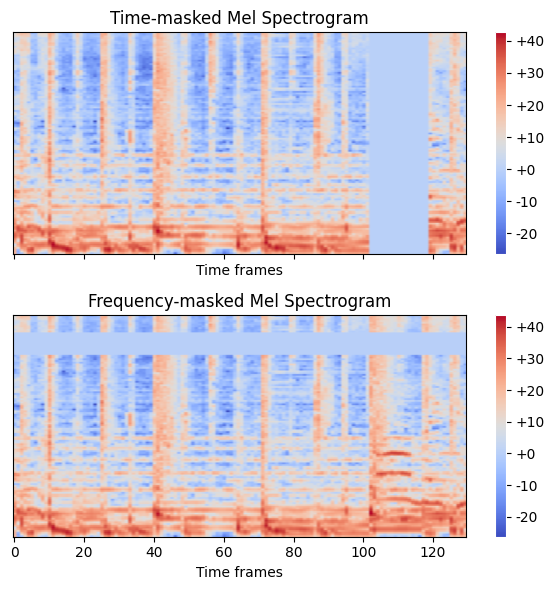

In [32]:
# Visualize data
time_masked_melspec_example = time_masked_data.numpy()
freq_masked_melspec_example = freq_masked_data.numpy()

fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True, sharey=True)
fig.patch.set_facecolor('white')

# ===== Time-masked MFCCs =====
axes[0].set_facecolor('white')

im0 = axes[0].imshow(
    time_masked_melspec_example,
    cmap='coolwarm',
    aspect='auto',
    origin='lower'
)

axes[0].set_title("Time-masked Mel Spectrogram", color='black')
axes[0].set_xlabel("Time frames", color='black')

# Remove y-axis labels & ticks
axes[0].set_ylabel("")
axes[0].set_yticks([])

axes[0].tick_params(axis='x', colors='black')
axes[0].tick_params(axis='y', colors='black')

for spine in axes[0].spines.values():
    spine.set_color('black')

cbar0 = fig.colorbar(im0, ax=axes[0], format="%+2.f")
cbar0.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar0.ax.get_yticklabels(), color='black')


# ===== Frequency-masked MFCCs =====
axes[1].set_facecolor('white')

im1 = axes[1].imshow(
    freq_masked_melspec_example,
    cmap='coolwarm',
    aspect='auto',
    origin='lower'
)

axes[1].set_title("Frequency-masked Mel Spectrogram", color='black')
axes[1].set_xlabel("Time frames", color='black')

# Remove y-axis labels & ticks
axes[1].set_ylabel("")
axes[1].set_yticks([])

axes[1].tick_params(axis='x', colors='black')
axes[1].tick_params(axis='y', colors='black')

for spine in axes[1].spines.values():
    spine.set_color('black')

cbar1 = fig.colorbar(im1, ax=axes[1], format="%+2.f")
cbar1.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar1.ax.get_yticklabels(), color='black')


# Layout
plt.tight_layout()

# # Save figure
# plt.savefig(
#     "masked_mfccs.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

plt.show()

### 8.2 Training the model with augmented data
We are going to create a new `train_step_with_augmentation()` and `train_with_augmentation` functions by altering our previous training functions in order to train the model with the augmented data. There is no need to use augmentation in validation and testing sets. The rest of the pipeline is the same. In the end we are going to plot the results to see if there is improvement.

In [33]:
# Creating the transform instance
from torchaudio import transforms as T

torch.manual_seed(RANDOM_SEED)

train_transforms = nn.Sequential(
    T.TimeMasking(time_mask_param=time_mask_param),
    T.FrequencyMasking(freq_mask_param=freq_mask_param)
)

# Create a train loop function
def train_step_with_augmentation(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               use_augmentation=True):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # Implement augmentation
        if use_augmentation:
            X = train_transforms(X)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [34]:
# Creating the function for training with data that have been augmented
def train_with_augmentation(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step_with_augmentation(model=model,
                                                            dataloader=train_dataloader,
                                                            loss_fn=loss_fn,
                                                            optimizer=optimizer,
                                                             use_augmentation=True)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [35]:
# Create a model and put it to device
NUM_CLASSES = 10
INPUT_SHAPE = (X.shape[1], X.shape[2]) # INPUT_SHAPE = (128, 130)

torch.manual_seed(RANDOM_SEED)
model_1 = MLPClassifierV0(input_shape=INPUT_SHAPE,
                          num_classes=NUM_CLASSES).to(device)
print(model_1)
print(next(model_1.parameters()).device)

MLPClassifierV0(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer_1): Linear(in_features=16640, out_features=512, bias=True)
  (layer_2): Linear(in_features=512, out_features=256, bias=True)
  (layer_3): Linear(in_features=256, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)
cuda:0


In [36]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=0.001,
                             weight_decay=0.001)

In [37]:
# Training the model using the train_with_augmentation function
# Set number of epochs
NUM_EPOCHS = 60

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train_with_augmentation(model=model_1,
                                        train_dataloader=train_dataloader,
                                        test_dataloader=validation_dataloader,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.1017 | train_acc: 0.2732 | test_loss: 1.7717 | test_acc: 0.3317
Epoch: 2 | train_loss: 1.8063 | train_acc: 0.3303 | test_loss: 1.8030 | test_acc: 0.3370
Epoch: 3 | train_loss: 1.7063 | train_acc: 0.3654 | test_loss: 1.6555 | test_acc: 0.3977
Epoch: 4 | train_loss: 1.6242 | train_acc: 0.4017 | test_loss: 1.5706 | test_acc: 0.4153
Epoch: 5 | train_loss: 1.6385 | train_acc: 0.4019 | test_loss: 1.6057 | test_acc: 0.3839
Epoch: 6 | train_loss: 1.5561 | train_acc: 0.4202 | test_loss: 1.5070 | test_acc: 0.4171
Epoch: 7 | train_loss: 1.4951 | train_acc: 0.4495 | test_loss: 1.5137 | test_acc: 0.4236
Epoch: 8 | train_loss: 1.4652 | train_acc: 0.4637 | test_loss: 1.5149 | test_acc: 0.4509
Epoch: 9 | train_loss: 1.3743 | train_acc: 0.4965 | test_loss: 1.4376 | test_acc: 0.4971
Epoch: 10 | train_loss: 1.4029 | train_acc: 0.4865 | test_loss: 1.5815 | test_acc: 0.4738
Epoch: 11 | train_loss: 1.3269 | train_acc: 0.5203 | test_loss: 1.4726 | test_acc: 0.4542
Epoch: 12 | train_l

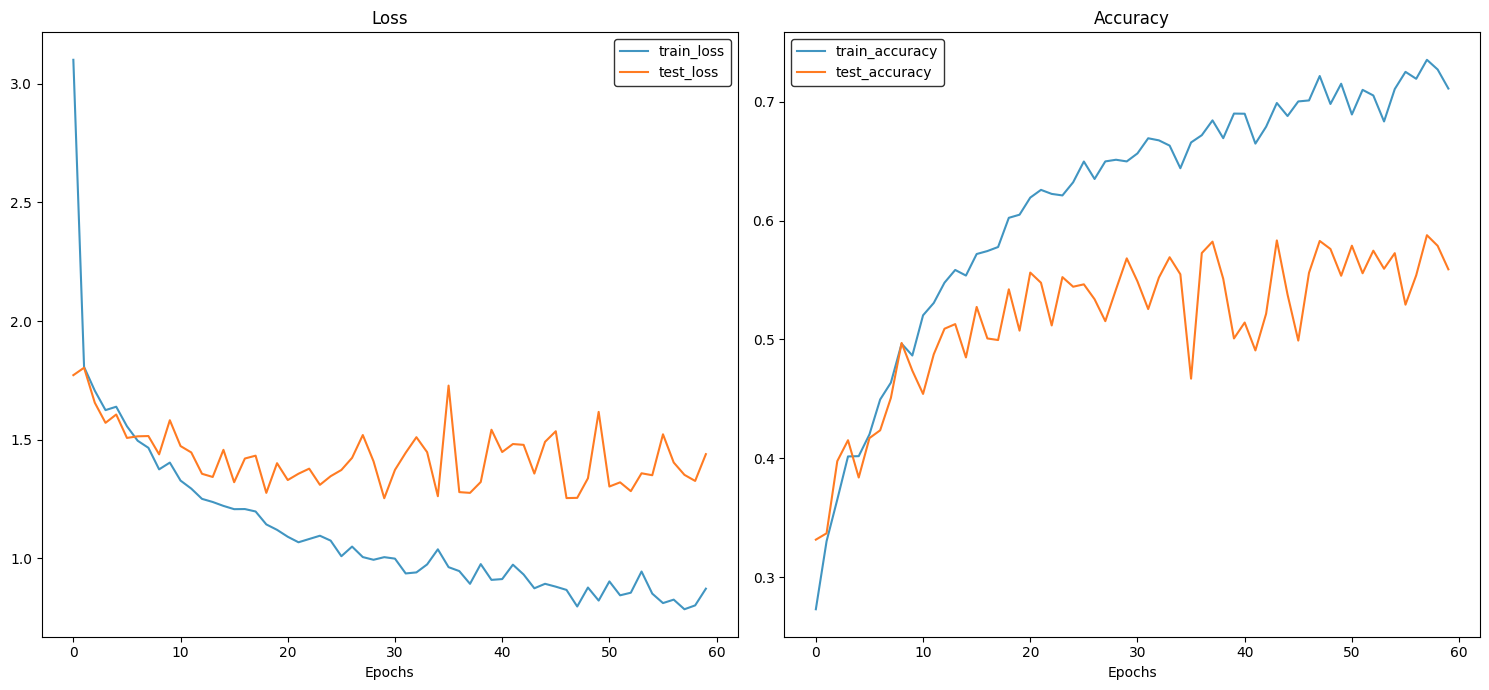

In [38]:
plot_loss_curves(model_1_results)

## 8. Use Early stopping to create the best model

We will stop the training on 30 epochs

In [39]:
# Create a model and put it to device
NUM_CLASSES = 10
INPUT_SHAPE = (X.shape[1], X.shape[2]) # INPUT_SHAPE = (130, 13)

torch.manual_seed(RANDOM_SEED)
model_2 = MLPClassifierV0(input_shape=INPUT_SHAPE,
                          num_classes=NUM_CLASSES).to(device)
print(model_2)
print(next(model_2.parameters()).device)

MLPClassifierV0(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer_1): Linear(in_features=16640, out_features=512, bias=True)
  (layer_2): Linear(in_features=512, out_features=256, bias=True)
  (layer_3): Linear(in_features=256, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)
cuda:0


In [40]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.parameters(),
                             lr=0.001,
                             weight_decay=0.001)

In [41]:
# Training the model using the train_with_augmentation function
# Set number of epochs
NUM_EPOCHS = 30

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_2_results = train_with_augmentation(model=model_2,
                                        train_dataloader=train_dataloader,
                                        test_dataloader=validation_dataloader,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.1017 | train_acc: 0.2732 | test_loss: 1.7717 | test_acc: 0.3317
Epoch: 2 | train_loss: 1.8063 | train_acc: 0.3303 | test_loss: 1.8030 | test_acc: 0.3370
Epoch: 3 | train_loss: 1.7063 | train_acc: 0.3654 | test_loss: 1.6555 | test_acc: 0.3977
Epoch: 4 | train_loss: 1.6242 | train_acc: 0.4017 | test_loss: 1.5706 | test_acc: 0.4153
Epoch: 5 | train_loss: 1.6385 | train_acc: 0.4019 | test_loss: 1.6057 | test_acc: 0.3839
Epoch: 6 | train_loss: 1.5561 | train_acc: 0.4202 | test_loss: 1.5070 | test_acc: 0.4171
Epoch: 7 | train_loss: 1.4951 | train_acc: 0.4495 | test_loss: 1.5137 | test_acc: 0.4236
Epoch: 8 | train_loss: 1.4652 | train_acc: 0.4637 | test_loss: 1.5149 | test_acc: 0.4509
Epoch: 9 | train_loss: 1.3743 | train_acc: 0.4965 | test_loss: 1.4376 | test_acc: 0.4971
Epoch: 10 | train_loss: 1.4029 | train_acc: 0.4865 | test_loss: 1.5815 | test_acc: 0.4738
Epoch: 11 | train_loss: 1.3269 | train_acc: 0.5203 | test_loss: 1.4726 | test_acc: 0.4542
Epoch: 12 | train_l

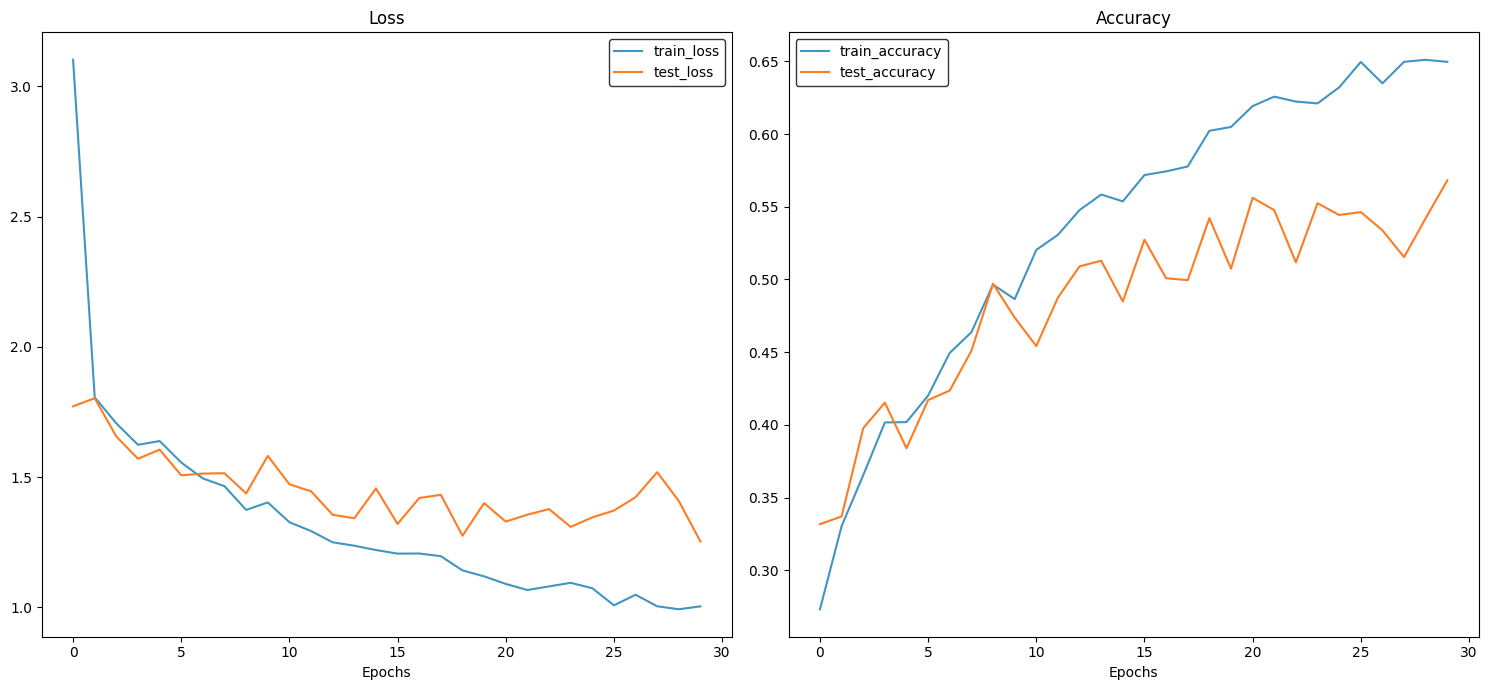

In [42]:
plot_loss_curves(model_2_results)

## 9. Evaluating our best model on never seen data

Finally, we are going to use the `test_dataloader` to evaluate `model_6` which was our best performing model.

In [43]:
# Evaluate the CNN on the test set
evaluation = test_step(model=model_2,
                       dataloader=test_dataloader,
                       loss_fn=loss_fn,
                       )
print(f"test loss = {evaluation[0]:.4f} | test acc = {evaluation[1]:.4f}")

test loss = 1.2408 | test acc = 0.5836


## 10. Creating a `predict()` function, to make predictions on unseen data

We are going to use `model_2` to make predictions. First we use the test dataloader to extract the first sample. Then we create the predict function that among other arguments, we can enter the index of the sample we want to predict. We see that we have 2499 indexes available.
The tensor that represents the sample has to be unsqueezed because the model expects a `batch_size` on dim=0. The model exports logits. Using `softmax()` we turn the logits into probabilities and with `argmax()` we take the index of the highest probability. This is actually the predicted index class. However, we can use `argmax()` right away without having the probabilites first. This is because logit values are respective to the probability values. This is actually the predicted index class. We also do that for time complexity reasons.

In [44]:
# Creating the predict() function
def predict(model: torch.nn.Module,
            X_test: torch.Tensor,
            y_test: torch.Tensor,
            index: int = 0,
            device: str = "cpu",
            classes: list = classes):

    X_sample = X_test[index].unsqueeze(0).to(device)  # (1, C, H, W)
    y_sample = y_test[index].item() if isinstance(y_test[index], torch.Tensor) else y_test[index]

    model.eval()
    with torch.inference_mode():
        logits = model(X_sample)
        predicted_index = torch.argmax(logits, dim=1).item()

    print(f"Target: {classes[y_sample]}, Predicted label: {classes[predicted_index]}")

In [45]:
# Checking shape of X_test. There are 2499 samples
X_test.shape

torch.Size([2499, 128, 130])

In [46]:
# Set random seed to define index.
np.random.seed(RANDOM_SEED) # remove this line to set a random index, for further testing
index = np.random.randint(len(X_test))

predict(model=model_2,
        X_test=X_test,
        y_test=y_test,
        index=index,
        device=device,
        classes=classes)

Target: country, Predicted label: country


## 15. Making a confusion matrix for further evaluation

For a good vizualization of our model's performance, we can use a confusion matrix. For that purpose we will use the `torchmetrics` and `mlxtend` library.
First we will make predictions on a test set and save the results on a tensor. Then we can use this tensor along with `y_test` which is a tensor containing the correct values for the labels of the test set.

In [47]:
# Importing libraries
import mlxtend
print(f"mlxtend version: {mlxtend.__version__}")
assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher. use pip install -q torchmetrics -U mlxtend"

mlxtend version: 0.24.0


In [48]:
# Make predictions on test_set and get tensor with predictions
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_1.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/79 [00:00<?, ?it/s]

In [49]:
# Importing libraries
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(classes), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=y_test)

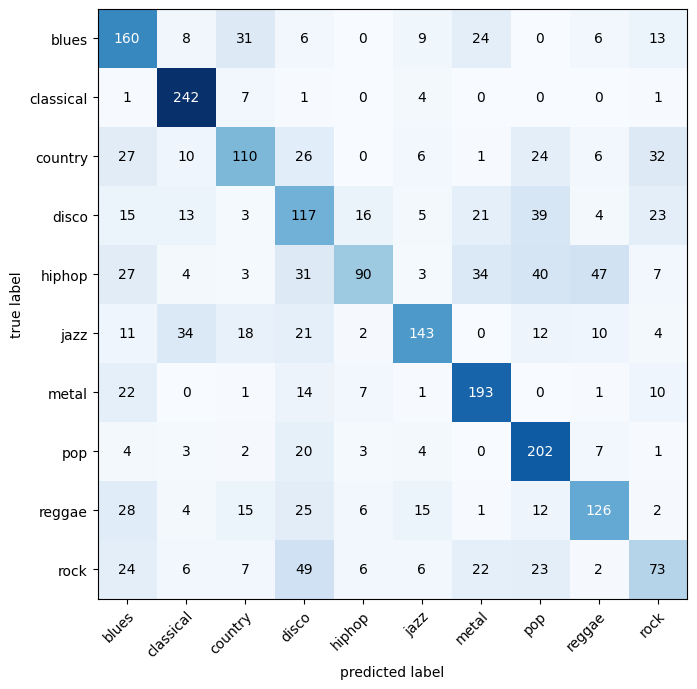

In [50]:
# Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),  # matplotlib likes working with NumPy
    class_names=classes,
    figsize=(10, 7)
)

# Figure & axes background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Axis labels styling
ax.set_xlabel("predicted label", color='black')
ax.set_ylabel("true label", color='black')

ax.tick_params(axis='x', colors='black', rotation=45)
ax.tick_params(axis='y', colors='black')

# Spines
for spine in ax.spines.values():
    spine.set_color('black')

# Cell text (numbers inside matrix)
# We take each tex
# Retrieve all text annotations added by plot_confusion_matrix
for text in ax.texts:
    text.set_color('white' if float(text.get_text()) > confmat_tensor.max() / 2 else 'black')

# Colorbar styling
if len(fig.axes) > 1:  # second axis = colorbar
    cbar_ax = fig.axes[1]
    cbar_ax.tick_params(color='black')
    plt.setp(cbar_ax.get_yticklabels(), color='black')

# Layout
plt.tight_layout()

# # Save
# plt.savefig(
#     "MLP_confusion_matrix.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

plt.show()